In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification

# Generate Synthetic Data

In [17]:
np.random.seed(42)

X_train = np.linspace(-1, 1, 20)

y_train = (
    0.5 * X_train
    + np.random.normal(0, 0.15, len(X_train))
)

In [18]:
X_test = np.linspace(-1, 1, 20)

y_test = (
    0.5 * X_test
    + np.random.normal(0, 0.15, len(X_test))
)

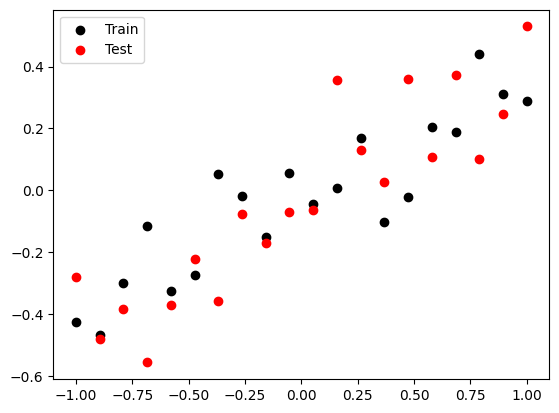

In [19]:
plt.scatter(X_train, y_train, c='black', label='Train')
plt.scatter(X_test, y_test, c='red', label='Test')

plt.legend()
plt.show()

In [22]:
model = Sequential()

model.add(Dense(128, input_dim = 1, activation='relu'))
model.add(Dense(128, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))

adam = Adam(learning_rate = 0.01)

model.compile(loss = 'mse', optimizer = adam, metrics = ['mse'])

history = model.fit(X_train, y_train, epochs = 500, validation_data = (X_test, y_test), verbose = False)

In [23]:
# evaluate the model

_, train_mse = model.evaluate(X_train, y_train, verbose =0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)

print('Train: {},, Test: {}'.format(train_mse, test_mse))

Train: 0.0008435010095126927,, Test: 0.04552202671766281


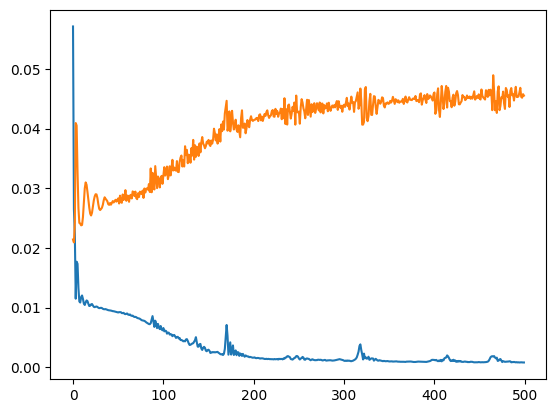

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [30]:
model = Sequential()

model.add(Dense(128, input_dim = 1, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'linear'))

adam = Adam(learning_rate = 0.01)

model.compile(loss = 'mse', optimizer = adam, metrics = ['mse'])

history = model.fit(X_train, y_train, epochs = 500, validation_data = (X_test, y_test), verbose = False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# evaluate the model

_, train_mse = model.evaluate(X_train, y_train, verbose =0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)

print('Train: {},, Test: {}'.format(train_mse, test_mse))

Train: 0.00970042496919632,, Test: 0.03386553004384041


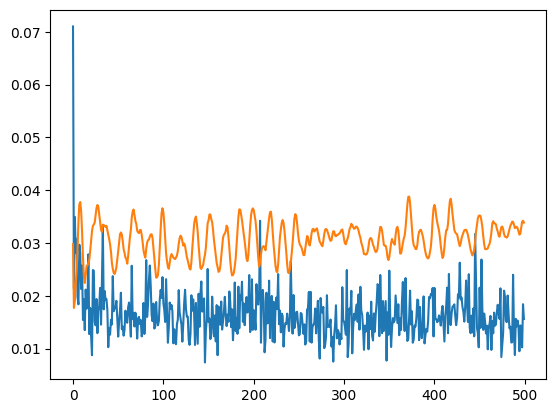

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [33]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


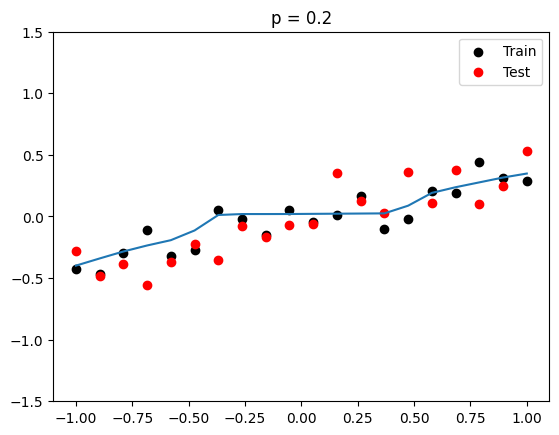

In [34]:
plt.figure()
plt.title("p = 0.2")

plt.scatter(X_train, y_train, c = 'black', label = 'Train')
plt.scatter(X_test, y_test, c = 'red', label = 'Test')

plt.plot(X_test, y_pred)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()